# 第11章 监测数据统计分析 - Python代码示例

本Notebook提供了教材第11章涉及的核心数据统计分析方法的Python实现代码。涵盖以下五个部分：
1. 基本统计分析：集中趋势、离散程度；
2. 概率密度函数估计：正态分布、高斯混合模型、核密度估计、功率谱密度；
3. 极值分析：区间极值法、过阈法；
4. 相关性分析：Pearson相关分析、典型相关分析；
5. 回归分析：线性回归、非线性回归。

**运行环境要求**：`numpy`, `scipy`, `scikit-learn`, `matplotlib`, `statsmodels`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import welch
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
from sklearn.cross_decomposition import CCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 设置绘图风格支持中文
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 1. 基本统计分析
复现教材【例11-1】：某城市桥梁某天振动数据基本统计分析。

In [2]:
# 例11-1 原始数据
data_11_1 = np.array([2.1, 2.0, 2.2, 2.5, 3.0, 7.8, 2.7, 2.4, 2.6, 2.9])

# 1.1 集中趋势
mean_val = np.mean(data_11_1)                   # 算术平均值
gmean_val = stats.gmean(data_11_1)              # 几何平均值
median_val = np.median(data_11_1)               # 中位数

# 1.2 离散程度
var_val = np.var(data_11_1, ddof=1)             # 样本方差 (n-1)
std_val = np.std(data_11_1, ddof=1)             # 样本标准差
range_val = np.ptp(data_11_1)                   # 极差
cv_val = (std_val / mean_val) * 100             # 变异系数 (%)

print("=== 例11-1 基本统计分析结果 ===")
print(f"算术平均值 X̄ = {mean_val:.4f}")
print(f"几何平均值 X̄g = {gmean_val:.4f}")
print(f"中位数 Me = {median_val:.4f}")
print(f"样本方差 S² = {var_val:.4f}")
print(f"样本标准差 σ = {std_val:.4f}")
print(f"极差 R = {range_val:.4f}")
print(f"变异系数 CV = {cv_val:.2f}%")
if cv_val > 15:
    print("【警告】变异系数大于15%，提示存在异常数据！")
    # 进一步分析异常值
    z_scores = (data_11_1 - mean_val) / std_val
    outliers = data_11_1[np.abs(z_scores) > 2]
    if len(outliers) > 0:
        print(f"异常值检测结果：{outliers}")

=== 例11-1 基本统计分析结果 ===
算术平均值 X̄ = 3.0200
几何平均值 X̄g = 2.7681
中位数 Me = 2.5500
样本方差 S² = 2.9284
样本标准差 σ = 1.7113
极差 R = 5.8000
变异系数 CV = 56.66%
【警告】变异系数大于15%，提示存在异常数据！
异常值检测结果：[7.8]


## 2. 概率密度函数估计
包含正态分布拟合、高斯混合模型(GMM)、核密度估计(KDE)与功率谱密度(PSD)。

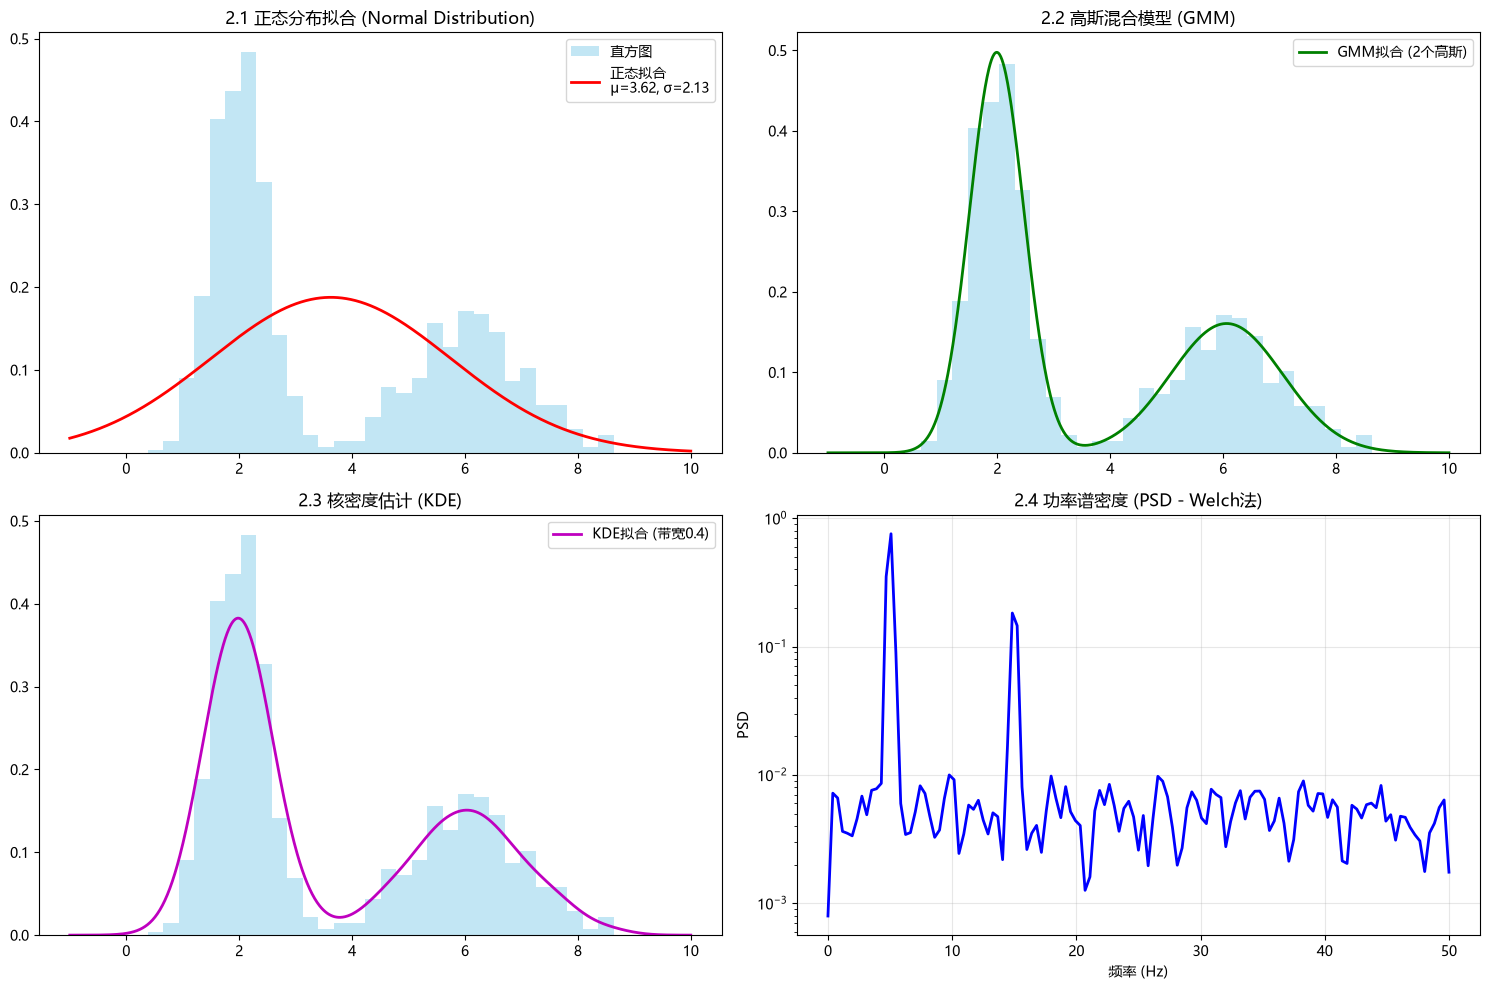

In [3]:
# 生成模拟监测数据：包含两个模态的振动响应（双峰分布）
np.random.seed(42)
data_bimodal = np.concatenate([
    np.random.normal(loc=2, scale=0.5, size=600),
    np.random.normal(loc=6, scale=1.0, size=400)
])
x_grid = np.linspace(-1, 10, 1000)

plt.figure(figsize=(15, 10))

# 2.1 正态分布拟合（单峰强制拟合双峰）
plt.subplot(2, 2, 1)
mu, std = stats.norm.fit(data_bimodal)
pdf_norm = stats.norm.pdf(x_grid, mu, std)
plt.hist(data_bimodal, bins=30, density=True, alpha=0.5, color='skyblue', label='直方图')
plt.plot(x_grid, pdf_norm, 'r-', lw=2, label=f'正态拟合\nμ={mu:.2f}, σ={std:.2f}')
plt.title('2.1 正态分布拟合 (Normal Distribution)')
plt.legend()

# 2.2 高斯混合模型 (GMM)
plt.subplot(2, 2, 2)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(data_bimodal.reshape(-1, 1))
logprob = gmm.score_samples(x_grid.reshape(-1, 1))
pdf_gmm = np.exp(logprob)
plt.hist(data_bimodal, bins=30, density=True, alpha=0.5, color='skyblue')
plt.plot(x_grid, pdf_gmm, 'g-', lw=2, label='GMM拟合 (2个高斯)')
plt.title('2.2 高斯混合模型 (GMM)')
plt.legend()

# 2.3 核密度估计 (KDE)
plt.subplot(2, 2, 3)
kde = KernelDensity(kernel='gaussian', bandwidth=0.4)
kde.fit(data_bimodal.reshape(-1, 1))
logprob_kde = kde.score_samples(x_grid.reshape(-1, 1))
pdf_kde = np.exp(logprob_kde)
plt.hist(data_bimodal, bins=30, density=True, alpha=0.5, color='skyblue')
plt.plot(x_grid, pdf_kde, 'm-', lw=2, label='KDE拟合 (带宽0.4)')
plt.title('2.3 核密度估计 (KDE)')
plt.legend()

# 2.4 功率谱密度 (PSD) - 平均周期图法(Welch方法)
plt.subplot(2, 2, 4)
fs = 100  # 采样频率 100Hz
t = np.arange(0, 10, 1/fs)
# 构造含噪声的信号：5Hz和15Hz正弦波
sig = np.sin(2*np.pi*5*t) + 0.5*np.sin(2*np.pi*15*t) + np.random.randn(len(t))*0.5
f, Pxx = welch(sig, fs, nperseg=256)
plt.semilogy(f, Pxx, 'b-', lw=2)
plt.title('2.4 功率谱密度 (PSD - Welch法)')
plt.xlabel('频率 (Hz)')
plt.ylabel('PSD')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 极值分析
演示广义极值分布（GEV，区间极值法）与广义帕累托分布（GPD，过阈法）的尾部拟合。

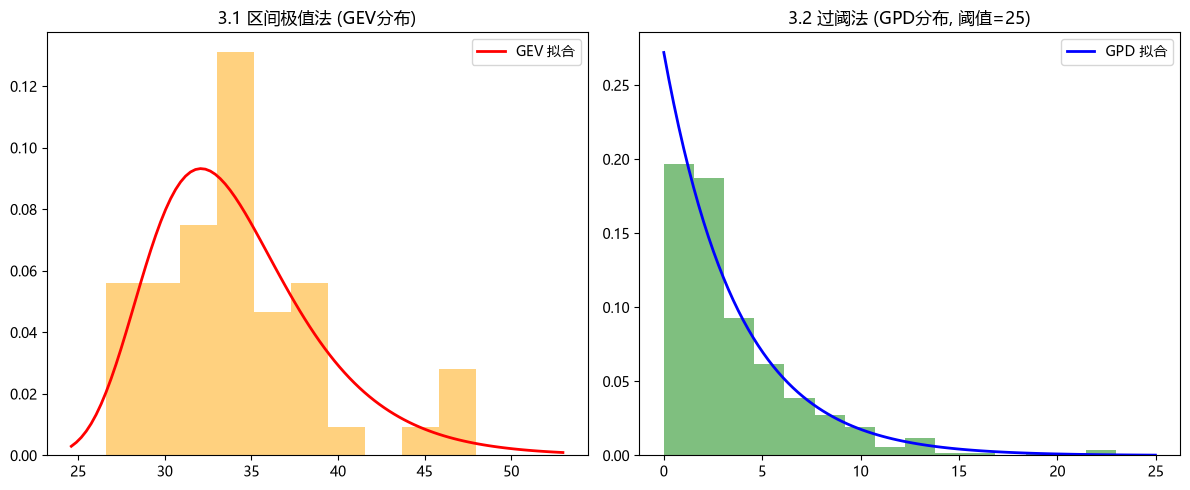

In [4]:
# 生成服从Weibull分布的极端风速数据
np.random.seed(0)
wind_speed = stats.weibull_min.rvs(c=2, loc=0, scale=15, size=5000)

# 3.1 区间极值法 (GEV)
# 将数据分为50个区间，取每个区间的最大值
block_maxima = np.array([np.max(wind_speed[i:i+100]) for i in range(0, 5000, 100)])
gev_params = stats.genextreme.fit(block_maxima)

# 3.2 过阈法 (GPD)
# 选取阈值 u = 25
u = 25
exceedances = wind_speed[wind_speed > u] - u
gpd_params = stats.genpareto.fit(exceedances, floc=0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(block_maxima, bins=10, density=True, alpha=0.5, color='orange')
x_gev = np.linspace(min(block_maxima)-2, max(block_maxima)+5, 100)
plt.plot(x_gev, stats.genextreme.pdf(x_gev, *gev_params), 'r-', lw=2, label='GEV 拟合')
plt.title('3.1 区间极值法 (GEV分布)')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(exceedances, bins=15, density=True, alpha=0.5, color='green')
x_gpd = np.linspace(0, max(exceedances)+2, 100)
plt.plot(x_gpd, stats.genpareto.pdf(x_gpd, *gpd_params), 'b-', lw=2, label='GPD 拟合')
plt.title(f'3.2 过阈法 (GPD分布, 阈值={u})')
plt.legend()

plt.tight_layout()
plt.show()

## 4. 相关性分析
复现教材【例11-3】Pearson相关分析，并演示典型相关分析(CCA)。

In [5]:
# 4.1 Pearson相关分析（例11-3）
# （注：教材例11-3中所给数据有错误，计算出来为负相关，但长期来看车辆通行频率和挠度应正相关）
y_deflection = np.array([5, 3, 7, 4, 2])    # 挠度 Y
x_freq = np.array([10, 15, 8, 12, 18])      # 车辆频率 X

r_xy, p_value = stats.pearsonr(x_freq, y_deflection)
print("=== 4.1 Pearson相关分析 (例11-3) ===")
print(f"相关系数 r = {r_xy:.4f}")
print(f"P值 = {p_value:.4f}")
if r_xy < 0:
    print("结论：挠度与车辆通过频率呈强负相关。")
else:
    print("结论：挠度与车辆通过频率呈正相关。")    

# 4.2 典型相关分析 (CCA)
# X组：两类荷载（温度，风速）；Y组：两类响应（位移，应变）
np.random.seed(1)
X_group = np.random.randn(100, 2)
Y_group = X_group @ np.array([[0.8, 0.2], [0.3, 0.9]]) + np.random.randn(100, 2)*0.1

cca = CCA(n_components=2)
cca.fit(X_group, Y_group)
X_c, Y_c = cca.transform(X_group, Y_group)

print("\n=== 4.2 典型相关分析 (CCA) ===")
for i in range(2):
    r_c = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
    print(f"第{i+1}对典型变量的相关系数 = {r_c:.4f}")

=== 4.1 Pearson相关分析 (例11-3) ===
相关系数 r = -0.9678
P值 = 0.0069
结论：挠度与车辆通过频率呈强负相关。

=== 4.2 典型相关分析 (CCA) ===
第1对典型变量的相关系数 = 0.9948
第2对典型变量的相关系数 = 0.9815


## 5. 回归分析
复现教材【例11-4】一元线性回归，并演示多项式非线性回归。

=== 5.1 一元线性回归 (例11-4) ===
经验回归方程: y = 0.0464x + 0.5670
决定系数 R² = 0.8646
均方根误差 RMSE = 0.1106

=== 5.2 多项式回归 ===
二次多项式回归方程: y = 0.000208x² + 0.0365x + 0.6767
二次多项式回归 R² = 0.8650
二次多项式回归 RMSE = 0.1104


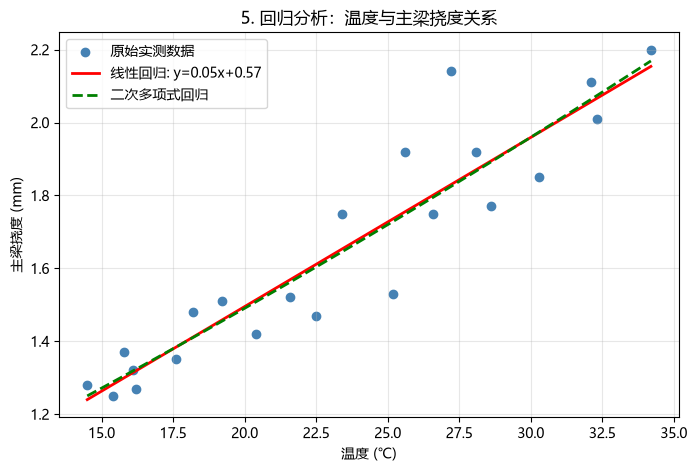

In [6]:
# 5.1 一元线性回归（例11-4）
temp = np.array([16.2, 15.4, 20.4, 22.5, 25.2, 30.3, 28.6, 26.6, 32.1, 34.2, 
                 32.3, 28.1, 27.2, 25.6, 23.4, 21.6, 16.1, 14.5, 15.8, 17.6, 18.2, 19.2])
deflection = np.array([1.27, 1.25, 1.42, 1.47, 1.53, 1.85, 1.77, 1.75, 2.11, 2.20, 
                       2.01, 1.92, 2.14, 1.92, 1.75, 1.52, 1.32, 1.28, 1.37, 1.35, 1.48, 1.51])

lr = LinearRegression()
lr.fit(temp.reshape(-1, 1), deflection)
b_hat = lr.coef_[0]
a_hat = lr.intercept_

print("=== 5.1 一元线性回归 (例11-4) ===")
print(f"经验回归方程: y = {b_hat:.4f}x + {a_hat:.4f}")

# 对拟合结果进行评价，并给出R²值以及RMSE等评价指标
y_pred = lr.predict(temp.reshape(-1, 1))
ss_res = np.sum((deflection - y_pred) ** 2)
ss_tot = np.sum((deflection - np.mean(deflection)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
rmse = np.sqrt(ss_res / len(deflection))
print(f"决定系数 R² = {r_squared:.4f}")
print(f"均方根误差 RMSE = {rmse:.4f}")

# 5.2 多项式回归（非线性回归）
# 将一元二次多项式转化为二元线性回归
poly = PolynomialFeatures(degree=2, include_bias=False)
temp_poly = poly.fit_transform(temp.reshape(-1, 1))
lr_poly = LinearRegression()
lr_poly.fit(temp_poly, deflection)

print("\n=== 5.2 多项式回归 ===")
print(f"二次多项式回归方程: y = {lr_poly.coef_[1]:.6f}x² + {lr_poly.coef_[0]:.4f}x + {lr_poly.intercept_:.4f}")

# 对拟合结果进行评价，并给出R²值以及RMSE等评价指标
y_pred_poly = lr_poly.predict(temp_poly)
ss_res_poly = np.sum((deflection - y_pred_poly) ** 2)
ss_tot_poly = np.sum((deflection - np.mean(deflection)) ** 2)
r_squared_poly = 1 - (ss_res_poly / ss_tot_poly)
rmse_poly = np.sqrt(ss_res_poly / len(deflection))
print(f"二次多项式回归 R² = {r_squared_poly:.4f}")
print(f"二次多项式回归 RMSE = {rmse_poly:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(temp, deflection, color='steelblue', label='原始实测数据')

x_range = np.linspace(min(temp), max(temp), 100).reshape(-1, 1)
plt.plot(x_range, lr.predict(x_range), 'r-', lw=2, label=f'线性回归: y={b_hat:.2f}x+{a_hat:.2f}')
plt.plot(x_range, lr_poly.predict(poly.transform(x_range)), 'g--', lw=2, label='二次多项式回归')

plt.title('5. 回归分析：温度与主梁挠度关系')
plt.xlabel('温度 (℃)')
plt.ylabel('主梁挠度 (mm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()